In [36]:
# ============================================================
# XAUUSD ELLIOTT WAVE BACKTEST — PREFERRED COUNT
# ============================================================
# Strategy:   Leading Diagonal (Wave 1 Minor) +
#             ABC Zigzag Short (Wave 2 Minor)
# Timeframe:  4 Hour
# Data:       GC=F Gold Futures via yfinance
# Capital:    $100,000
# By:         Munyaradzi Nyika | Wave & Code
# Research:   waveandcode.substack.com
# Code:       github.com/mnyika-quant
# Signals:    t.me/waveandcodesignals
# ============================================================

!pip install yfinance pandas numpy matplotlib --quiet

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully')

All libraries imported successfully


In [37]:
# ============================================================
# DATA PREPARATION
#
# Source:     GC=F Gold Futures via yfinance
# Method:     Download 1H bars then resample to 4H
# Reason:     yfinance does not offer 4H directly
#             Resampling 1H to 4H gives clean 4H OHLCV bars
#
# Date range: Nov 2024 to Mar 2026
#             Covers full wave structure from diagonal start
#             at 4,655.23 through to current price action
# ============================================================

# Download 1H data
raw = yf.download(
    'GC=F',
    start='2024-11-01',
    end='2026-03-16',
    interval='1h',
    auto_adjust=True,
    progress=False
)

# Flatten multi-level columns if present
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)

# Resample 1H to 4H OHLCV
gold = raw.resample('4h').agg({
    'Open':   'first',
    'High':   'max',
    'Low':    'min',
    'Close':  'last',
    'Volume': 'sum'
}).dropna()

print(f'Shape:          {gold.shape}')
print(f'Date range:     {gold.index[0]} to {gold.index[-1]}')
print(f'Price range:    {gold["Low"].min():.2f} to {gold["High"].max():.2f}')
print(f'Total 4H bars:  {len(gold)}')
print()
print(gold[['Open','High','Low','Close']].tail(5))


Shape:          (2113, 5)
Date range:     2024-11-01 04:00:00+00:00 to 2026-03-16 00:00:00+00:00
Price range:    2541.50 to 5626.80
Total 4H bars:  2113

Price                             Open         High          Low        Close
Datetime                                                                     
2026-03-13 12:00:00+00:00  5113.000000  5128.500000  5032.200195  5039.100098
2026-03-13 16:00:00+00:00  5038.799805  5068.100098  5014.100098  5022.000000
2026-03-13 20:00:00+00:00  5022.299805  5061.700195  5017.000000  5061.700195
2026-03-15 20:00:00+00:00  5027.600098  5030.000000  4970.100098  5000.600098
2026-03-16 00:00:00+00:00  5001.100098  5035.399902  4986.000000  4999.600098


In [38]:
# ============================================================
# DATA HEALTH CHECK
#
# Verify that all key wave levels fall within the
# price range of our dataset before running the backtest
# All checks must return True to proceed
# ============================================================

print('=== DATA HEALTH CHECK ===')
print()
print(f'Total 4H bars:    {len(gold)}')
print(f'Missing values:')
print(gold.isnull().sum())
print()
print('=== KEY LEVEL CHECKS ===')
print(f'  Diagonal start 4,655.23 in range:  {gold["High"].max() >= 4655.23 >= gold["Low"].min()}')
print(f'  Diagonal end   5,419.66 in range:  {gold["High"].max() >= 5419.66 >= gold["Low"].min()}')
print(f'  Wave B         5,238.78 in range:  {gold["High"].max() >= 5238.78 >= gold["Low"].min()}')
print(f'  Cond trigger   4,996.23 in range:  {gold["High"].max() >= 4996.23 >= gold["Low"].min()}')
print(f'  Target         4,815.40 in range:  {gold["High"].max() >= 4815.40 >= gold["Low"].min()}')
print(f'  Invalidation   4,655.23 in range:  {gold["High"].max() >= 4655.23 >= gold["Low"].min()}')
print()
print('All True = data is ready. Any False = adjust date range.')


=== DATA HEALTH CHECK ===

Total 4H bars:    2113
Missing values:
Price
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

=== KEY LEVEL CHECKS ===
  Diagonal start 4,655.23 in range:  True
  Diagonal end   5,419.66 in range:  True
  Wave B         5,238.78 in range:  True
  Cond trigger   4,996.23 in range:  True
  Target         4,815.40 in range:  True
  Invalidation   4,655.23 in range:  True

All True = data is ready. Any False = adjust date range.


In [39]:
# ============================================================
# RSI INDICATOR
#
# RSI (Relative Strength Index) measures the speed and
# magnitude of recent price changes to evaluate whether
# an asset is overbought or oversold
#
# Formula:
#   RSI = 100 - (100 / (1 + RS))
#   RS  = Average Gain / Average Loss over N periods
#
# Settings used:
#   RSI period:    14 bars
#   RSI MA period: 14 bar rolling mean of RSI
#
# Signal logic:
#   ENTRY — RSI crosses BELOW its MA
#     Momentum has shifted to the downside
#     Confirms our bearish ABC zigzag wave count
#
#   EXIT — RSI crosses ABOVE its MA
#     Momentum has shifted back to the upside
#     Corrective wave may be complete — close trade
# ============================================================

def calculate_rsi(series, period=14):
    """
    Calculate RSI using simple rolling average method
    period: lookback window (default 14 bars)
    """
    delta    = series.diff()
    gain     = delta.where(delta > 0, 0)
    loss     = -delta.where(delta < 0, 0)
    avg_gain = gain.rolling(window=period).mean()
    avg_loss = loss.rolling(window=period).mean()
    rs       = avg_gain / avg_loss
    rsi      = 100 - (100 / (1 + rs))
    return rsi

# Calculate RSI and RSI MA
gold['RSI']    = calculate_rsi(gold['Close'], period=14)
gold['RSI_MA'] = gold['RSI'].rolling(window=14).mean()

# Detect RSI crossovers
# Cross below: RSI was above MA last bar, now below MA
gold['RSI_cross_below'] = (
    (gold['RSI'] < gold['RSI_MA']) &
    (gold['RSI'].shift(1) >= gold['RSI_MA'].shift(1))
)

# Cross above: RSI was below MA last bar, now above MA
gold['RSI_cross_above'] = (
    (gold['RSI'] > gold['RSI_MA']) &
    (gold['RSI'].shift(1) <= gold['RSI_MA'].shift(1))
)

print('RSI calculated successfully')
print()
print(gold[['Close','RSI','RSI_MA']].dropna().tail(10))


RSI calculated successfully

Price                            Close        RSI     RSI_MA
Datetime                                                    
2026-03-12 16:00:00+00:00  5091.700195  36.574746  58.298425
2026-03-12 20:00:00+00:00  5101.500000  27.287854  55.161190
2026-03-13 00:00:00+00:00  5119.200195  34.714529  53.454294
2026-03-13 04:00:00+00:00  5089.500000  31.670935  51.724092
2026-03-13 08:00:00+00:00  5112.899902  35.210814  50.054543
2026-03-13 12:00:00+00:00  5039.100098  29.342352  46.768447
2026-03-13 16:00:00+00:00  5022.000000  29.152095  43.906146
2026-03-13 20:00:00+00:00  5061.700195  36.855762  41.992188
2026-03-15 20:00:00+00:00  5000.600098  29.675497  39.183898
2026-03-16 00:00:00+00:00  4999.600098  33.221805  37.596318


In [40]:
# ============================================================
# ELLIOTT WAVE STRUCTURE — PREFERRED COUNT — VERSION 2
#
# VERSION 2 UPGRADES:
# 1. Partial exit at Wave C = 0.618 of Wave A (4,977.13)
#    — If Trades 3 & 4 active: Close Trades 1 & 2, move T3&4 to break even
#    — If Trades 3 & 4 not active: Move T1&2 stop to 4,978.13
# 2. Full profit tracking in dollars on every bar
# 3. Locked in profit tracking after partial exits
# 4. Complete position lifecycle documentation
#
# WAVE C FIBONACCI LEVELS:
#   Wave A length:        423.38 points (5,419.66 - 4,996.28)
#   Wave C = 0.618 x A:  4,977.13 — minimum zigzag target
#   Wave C = 1.000 x A:  4,815.40 — full target
#
# CONTRACT SPECIFICATION:
#   Contract size: 100 ounces per lot
#   Value per point per lot: $100
#   Capital: $100,000
#
# POSITION LIFECYCLE:
#   Stage 1: Entry Trades 1 & 2 at RSI signal
#   Stage 2: Conditional entry Trades 3 & 4 at 4,996.23
#            Move Trades 1 & 2 to break even
#   Stage 3: Wave C = 0.618 at 4,977.13
#            If T3&4 active — close T1&2, move T3&4 to break even
#            If T3&4 not active — move T1&2 stop to 4,978.13
#   Stage 4: Full target at 4,815.40 — close all remaining
#   Stage 5: Early exit — RSI crosses above MA
#   Stage 6: Stop hit — close relevant lots
# ============================================================

# Key levels
WAVE_B_HIGH         = 5238.78   # Wave B end — entry zone
STOP_INITIAL        = 5248.78   # Stop Trades 1 & 2
CONDITIONAL_TRIGGER = 4996.23   # Triggers Trades 3 & 4
STOP_TRADES_34      = 5191.71   # Stop Trades 3 & 4
WAVE_C_618          = 4977.13   # Wave C = 0.618 x Wave A
PROTECTED_STOP      = 4978.13   # One point above 0.618 level
TARGET              = 4815.40   # Wave C = Wave A — full target
INVALIDATION        = 4655.23   # Diagonal invalidation
DIAGONAL_START      = 4655.23
DIAGONAL_END        = 5419.66
WAVE_A_LOW          = 4996.28
WAVE_B_DATE         = pd.Timestamp('2026-03-10', tz='UTC')

# Contract specification
CONTRACT_SIZE       = 100       # Ounces per lot
VALUE_PER_POINT     = 100       # Dollars per point per lot
CAPITAL             = 100000    # Simulated capital

# Initialise tracking columns
gold['position']    = 0
gold['stop_level']  = np.nan

# State variables
trades_1_2_active   = False
trades_3_4_active   = False
trades_1_2_closed   = False
break_even_moved_12 = False
break_even_moved_34 = False
protected_stop_set  = False
entry_price_12      = None
entry_price_34      = None
stop_12             = STOP_INITIAL
stop_34             = STOP_TRADES_34
total_position      = 0
locked_in_profit    = 0
trade_log           = []

# ============================================================
# PROFIT CALCULATION FUNCTION
# Calculates unrealised profit on active lots
# Plus any locked in profit from closed partial positions
# ============================================================

def calculate_profit(current_price, entry_12, entry_34,
                     active_12, active_34, lots_12, lots_34,
                     locked_profit):
    unrealised = 0
    if active_12 and entry_12 is not None:
        unrealised += (entry_12 - current_price) * VALUE_PER_POINT * lots_12
    if active_34 and entry_34 is not None:
        unrealised += (entry_34 - current_price) * VALUE_PER_POINT * lots_34
    return round(unrealised + locked_profit, 2)

# ============================================================
# BACKTEST LOOP
# ============================================================

for i in range(1, len(gold)):

    current_close   = gold['Close'].iloc[i]
    current_high    = gold['High'].iloc[i]
    current_low     = gold['Low'].iloc[i]
    rsi_cross_below = gold['RSI_cross_below'].iloc[i]
    rsi_cross_above = gold['RSI_cross_above'].iloc[i]
    idx             = gold.index[i]

    # ----------------------------------------------------------
    # ENTRY TRADES 1 & 2
    # Five conditions must all be True:
    # 1. No active trade
    # 2. Price below Wave B high
    # 3. Price above invalidation — valid zone only
    # 4. RSI crosses below MA — momentum confirmation
    # 5. Date on or after Wave B completion 10 March 2026
    # ----------------------------------------------------------
    if (not trades_1_2_active
            and not trades_1_2_closed
            and current_close < WAVE_B_HIGH
            and current_close > INVALIDATION
            and rsi_cross_below
            and idx >= WAVE_B_DATE):

        trades_1_2_active = True
        entry_price_12    = current_close
        stop_12           = STOP_INITIAL
        total_position    = 2
        gold.loc[idx, 'position']   = -total_position
        gold.loc[idx, 'stop_level'] = stop_12

        current_profit = calculate_profit(
            current_close, entry_price_12, entry_price_34,
            trades_1_2_active, trades_3_4_active, 2, 2,
            locked_in_profit
        )

        trade_log.append({
            'Event':          'ENTRY — Trades 1 & 2',
            'Date':           idx,
            'Price':          round(current_close, 2),
            'Lots':           2,
            'Stop':           stop_12,
            'Locked Profit':  locked_in_profit,
            'Running Profit': current_profit,
            'Total Equity':   round(CAPITAL + current_profit, 2)
        })

    # ----------------------------------------------------------
    # CONDITIONAL ENTRY TRADES 3 & 4
    # Four conditions must all be True:
    # 1. Trades 1 & 2 active
    # 2. Trades 3 & 4 not yet triggered
    # 3. Price breaks below 4,996.23
    # 4. Entry price was above 4,996.23
    # Action: Add 2 lots — move T1&2 stop to break even
    # ----------------------------------------------------------
    elif (trades_1_2_active
              and not trades_3_4_active
              and current_close < CONDITIONAL_TRIGGER
              and entry_price_12 > CONDITIONAL_TRIGGER):

        trades_3_4_active   = True
        entry_price_34      = current_close
        break_even_moved_12 = True
        stop_12             = entry_price_12
        stop_34             = STOP_TRADES_34
        total_position      = 4
        gold.loc[idx, 'position']   = -total_position
        gold.loc[idx, 'stop_level'] = stop_34

        current_profit = calculate_profit(
            current_close, entry_price_12, entry_price_34,
            trades_1_2_active, trades_3_4_active, 2, 2,
            locked_in_profit
        )

        trade_log.append({
            'Event':          'ENTRY T3&4 | T1&2 → BREAK EVEN',
            'Date':           idx,
            'Price':          round(current_close, 2),
            'Lots':           4,
            'Stop':           stop_34,
            'Locked Profit':  locked_in_profit,
            'Running Profit': current_profit,
            'Total Equity':   round(CAPITAL + current_profit, 2)
        })

    # ----------------------------------------------------------
    # EXIT CONDITIONS
    # ----------------------------------------------------------
    if trades_1_2_active or trades_3_4_active:

        # --------------------------------------------------
        # STAGE 3A — WAVE C = 0.618 OF WAVE A
        # Trades 3 & 4 ARE active
        # Close Trades 1 & 2 — lock in profit
        # Move Trades 3 & 4 stop to break even at 4,996.23
        # --------------------------------------------------
        if (current_low <= WAVE_C_618
                and trades_1_2_active
                and trades_3_4_active
                and not trades_1_2_closed):

            # Calculate locked profit on Trades 1 & 2
            profit_12       = (entry_price_12 - WAVE_C_618) * VALUE_PER_POINT * 2
            locked_in_profit += profit_12
            trades_1_2_active = False
            trades_1_2_closed = True
            break_even_moved_34 = True
            stop_34         = entry_price_34
            total_position  = 2
            gold.loc[idx, 'position']   = -total_position
            gold.loc[idx, 'stop_level'] = stop_34

            current_profit = calculate_profit(
                current_close, entry_price_12, entry_price_34,
                trades_1_2_active, trades_3_4_active, 2, 2,
                locked_in_profit
            )

            trade_log.append({
                'Event':          'EXIT T1&2 AT 0.618 | T3&4 → BREAK EVEN',
                'Date':           idx,
                'Price':          WAVE_C_618,
                'Lots':           2,
                'Stop':           stop_34,
                'Locked Profit':  round(locked_in_profit, 2),
                'Running Profit': current_profit,
                'Total Equity':   round(CAPITAL + current_profit, 2)
            })

        # --------------------------------------------------
        # STAGE 3B — WAVE C = 0.618 OF WAVE A
        # Trades 3 & 4 NOT active
        # Move Trades 1 & 2 stop to 4,978.13
        # One point above 0.618 level — protect profit
        # --------------------------------------------------
        elif (current_low <= WAVE_C_618
                  and trades_1_2_active
                  and not trades_3_4_active
                  and not protected_stop_set):

            protected_stop_set = True
            stop_12            = PROTECTED_STOP
            gold.loc[idx, 'stop_level'] = stop_12

            current_profit = calculate_profit(
                current_close, entry_price_12, entry_price_34,
                trades_1_2_active, trades_3_4_active, 2, 2,
                locked_in_profit
            )

            trade_log.append({
                'Event':          'STOP TIGHTENED TO 4,978.13 — T3&4 NOT ACTIVE',
                'Date':           idx,
                'Price':          round(current_close, 2),
                'Lots':           2,
                'Stop':           stop_12,
                'Locked Profit':  locked_in_profit,
                'Running Profit': current_profit,
                'Total Equity':   round(CAPITAL + current_profit, 2)
            })

        # --------------------------------------------------
        # EXIT 1 — FULL TARGET HIT AT 4,815.40
        # Close all remaining active lots
        # --------------------------------------------------
        elif (current_low <= TARGET
                  and (trades_1_2_active or trades_3_4_active)):

            if trades_1_2_active:
                profit_12        = (entry_price_12 - TARGET) * VALUE_PER_POINT * 2
                locked_in_profit += profit_12
                trades_1_2_active = False

            if trades_3_4_active:
                profit_34        = (entry_price_34 - TARGET) * VALUE_PER_POINT * 2
                locked_in_profit += profit_34
                trades_3_4_active = False

            total_position = 0
            gold.loc[idx, 'position'] = 0

            trade_log.append({
                'Event':          'EXIT — FULL TARGET HIT 4,815.40',
                'Date':           idx,
                'Price':          TARGET,
                'Lots':           0,
                'Stop':           None,
                'Locked Profit':  round(locked_in_profit, 2),
                'Running Profit': round(locked_in_profit, 2),
                'Total Equity':   round(CAPITAL + locked_in_profit, 2)
            })
            trades_1_2_closed = False

        # --------------------------------------------------
        # EXIT 2 — RSI CROSSED ABOVE MA
        # Close all active lots at market
        # --------------------------------------------------
        elif (rsi_cross_above
                  and current_close < (entry_price_12 or current_close)):

            if trades_1_2_active:
                profit_12        = (entry_price_12 - current_close) * VALUE_PER_POINT * 2
                locked_in_profit += profit_12
                trades_1_2_active = False

            if trades_3_4_active:
                profit_34        = (entry_price_34 - current_close) * VALUE_PER_POINT * 2
                locked_in_profit += profit_34
                trades_3_4_active = False

            total_position = 0
            gold.loc[idx, 'position'] = 0

            trade_log.append({
                'Event':          'EXIT — RSI CROSSED ABOVE MA',
                'Date':           idx,
                'Price':          round(current_close, 2),
                'Lots':           0,
                'Stop':           None,
                'Locked Profit':  round(locked_in_profit, 2),
                'Running Profit': round(locked_in_profit, 2),
                'Total Equity':   round(CAPITAL + locked_in_profit, 2)
            })
            trades_1_2_closed = False

        # --------------------------------------------------
        # EXIT 3 — STOP HIT TRADES 3 & 4
        # --------------------------------------------------
        elif (trades_3_4_active
                  and current_high >= stop_34):

            profit_34        = (entry_price_34 - stop_34) * VALUE_PER_POINT * 2
            locked_in_profit += profit_34
            trades_3_4_active = False
            total_position    = 2 if trades_1_2_active else 0
            gold.loc[idx, 'position'] = -total_position

            current_profit = calculate_profit(
                current_close, entry_price_12, entry_price_34,
                trades_1_2_active, trades_3_4_active, 2, 2,
                locked_in_profit
            )

            trade_log.append({
                'Event':          f'EXIT T3&4 — STOP HIT {stop_34}',
                'Date':           idx,
                'Price':          stop_34,
                'Lots':           total_position,
                'Stop':           stop_12 if trades_1_2_active else None,
                'Locked Profit':  round(locked_in_profit, 2),
                'Running Profit': current_profit,
                'Total Equity':   round(CAPITAL + current_profit, 2)
            })

        # --------------------------------------------------
        # EXIT 4 — STOP HIT TRADES 1 & 2
        # --------------------------------------------------
        elif (trades_1_2_active
                  and not trades_3_4_active
                  and current_high >= stop_12):

            profit_12        = (entry_price_12 - stop_12) * VALUE_PER_POINT * 2
            locked_in_profit += profit_12
            trades_1_2_active = False
            total_position    = 0
            gold.loc[idx, 'position'] = 0

            trade_log.append({
                'Event':          f'EXIT T1&2 — STOP HIT {stop_12}',
                'Date':           idx,
                'Price':          stop_12,
                'Lots':           0,
                'Stop':           None,
                'Locked Profit':  round(locked_in_profit, 2),
                'Running Profit': round(locked_in_profit, 2),
                'Total Equity':   round(CAPITAL + locked_in_profit, 2)
            })
            trades_1_2_closed = False

        # --------------------------------------------------
        # NO EXIT — HOLD POSITION
        # Update running profit on every bar
        # --------------------------------------------------
        else:
            gold.loc[idx, 'position'] = -total_position

            current_profit = calculate_profit(
                current_close, entry_price_12, entry_price_34,
                trades_1_2_active, trades_3_4_active, 2, 2,
                locked_in_profit
            )
            gold.loc[idx, 'stop_level'] = stop_34 if trades_3_4_active else stop_12

# ============================================================
# TRADE LOG SUMMARY
# ============================================================
print('=== TRADE LOG — VERSION 2 ===')
print()
trade_df = pd.DataFrame(trade_log)
if len(trade_df) > 0:
    print(f'Total trade events:  {len(trade_df)}')
    print()
    print('Event summary:')
    print(trade_df['Event'].value_counts())
    print()
    print('Full trade log:')
    print(trade_df.to_string(index=False))
    print()
    print('=== FINAL ACCOUNT STATUS ===')
    print(f'  Starting Capital:    ${CAPITAL:>12,.2f}')
    print(f'  Locked In Profit:    ${locked_in_profit:>12,.2f}')
    print(f'  Final Equity:        ${CAPITAL + locked_in_profit:>12,.2f}')
    print(f'  Total Return:        {(locked_in_profit/CAPITAL)*100:>11.2f}%')
else:
    print('No trades fired — entry conditions not met in dataset')

# Save to CSV
trade_df.to_csv('trade_log_v2.csv', index=False)
print()
print('Trade log saved as trade_log_v2.csv')


=== TRADE LOG — VERSION 2 ===

Total trade events:  3

Event summary:
Event
ENTRY — Trades 1 & 2                            1
STOP TIGHTENED TO 4,978.13 — T3&4 NOT ACTIVE    1
EXIT T1&2 — STOP HIT 4978.13                    1
Name: count, dtype: int64

Full trade log:
                                       Event                      Date   Price  Lots    Stop  Locked Profit  Running Profit  Total Equity
                        ENTRY — Trades 1 & 2 2026-03-11 20:00:00+00:00 5140.00     2 5248.78            0.0            0.00     100000.00
STOP TIGHTENED TO 4,978.13 — T3&4 NOT ACTIVE 2026-03-15 20:00:00+00:00 5000.60     2 4978.13            0.0        27879.98     127879.98
                EXIT T1&2 — STOP HIT 4978.13 2026-03-16 00:00:00+00:00 4978.13     0     NaN        32374.0        32374.00     132374.00

=== FINAL ACCOUNT STATUS ===
  Starting Capital:    $  100,000.00
  Locked In Profit:    $   32,374.00
  Final Equity:        $  132,374.00
  Total Return:              32.37%

T

In [41]:
# ============================================================
# PERFORMANCE METRICS
#
# LOG RETURNS
#   log_return = ln(Price_t / Price_t-1)
#   More accurate than simple returns for compounding
#
# STRATEGY RETURNS
#   strategy_return = position(t-1) * log_return * -1
#   position(t-1) — use prior bar to avoid lookahead bias
#   multiply by -1 — we are SHORT so gains come from drops
#
# SHARPE RATIO
#   Sharpe = (Mean Return / Std Return) * sqrt(bars per year)
#   4H bars per year = 6 bars per day * 252 days = 1,512
#   Above 1.0 = good | Above 2.0 = excellent
#
# MAX DRAWDOWN
#   Largest peak to trough decline in equity curve
#   Measures worst case loss from any high point
#
# WIN RATE
#   Percentage of active bars with positive return
#   50% or above on a short strategy in a bull market
#   is a strong result
# ============================================================

# Calculate returns
gold['log_return']          = np.log(gold['Close'] / gold['Close'].shift(1))
gold['strategy_return']     = gold['position'].shift(1) * gold['log_return'] * -1
gold['cumulative_market']   = gold['log_return'].cumsum().apply(np.exp)
gold['cumulative_strategy'] = gold['strategy_return'].cumsum().apply(np.exp)

# Isolate return series
strategy_returns = gold['strategy_return'].dropna()
market_returns   = gold['log_return'].dropna()

# 4H bars per year
bars_per_year = 6 * 252

# Sharpe ratios
sharpe_strategy = (
    (strategy_returns.mean() / strategy_returns.std())
    * np.sqrt(bars_per_year)
    if strategy_returns.std() != 0 else 0
)
sharpe_market = (
    (market_returns.mean() / market_returns.std())
    * np.sqrt(bars_per_year)
    if market_returns.std() != 0 else 0
)

# Max drawdown
rolling_max  = gold['cumulative_strategy'].cummax()
drawdown     = (gold['cumulative_strategy'] - rolling_max) / rolling_max
max_drawdown = drawdown.min()

# Win rate
active_bars = strategy_returns[strategy_returns != 0]
win_rate    = (
    (active_bars > 0).sum() / len(active_bars)
    if len(active_bars) > 0 else 0
)

# Total returns
strategy_total = (gold['cumulative_strategy'].iloc[-1] - 1) * 100
market_total   = (gold['cumulative_market'].iloc[-1] - 1) * 100

# Print results
print('=' * 52)
print('      XAUUSD BACKTEST — PERFORMANCE METRICS')
print('=' * 52)
print(f'  Strategy Return:     {strategy_total:>10.2f}%')
print(f'  Market Return:       {market_total:>10.2f}%')
print(f'  Outperformance:      {strategy_total - market_total:>10.2f}%')
print(f'  Strategy Sharpe:     {sharpe_strategy:>10.2f}')
print(f'  Market Sharpe:       {sharpe_market:>10.2f}')
print(f'  Max Drawdown:        {max_drawdown * 100:>10.2f}%')
print(f'  Win Rate:            {win_rate * 100:>10.2f}%')
print('=' * 52)
print()
print('NOTE: Market return reflects Gold bull run.')
print('This is a SHORT strategy targeting one specific')
print('corrective setup. The relevant measure is risk')
print('management quality and directional accuracy.')


      XAUUSD BACKTEST — PERFORMANCE METRICS
  Strategy Return:          -5.35%
  Market Return:            81.18%
  Outperformance:          -86.53%
  Strategy Sharpe:          -0.87
  Market Sharpe:             1.90
  Max Drawdown:             -7.11%
  Win Rate:                 46.15%

NOTE: Market return reflects Gold bull run.
This is a SHORT strategy targeting one specific
corrective setup. The relevant measure is risk
management quality and directional accuracy.


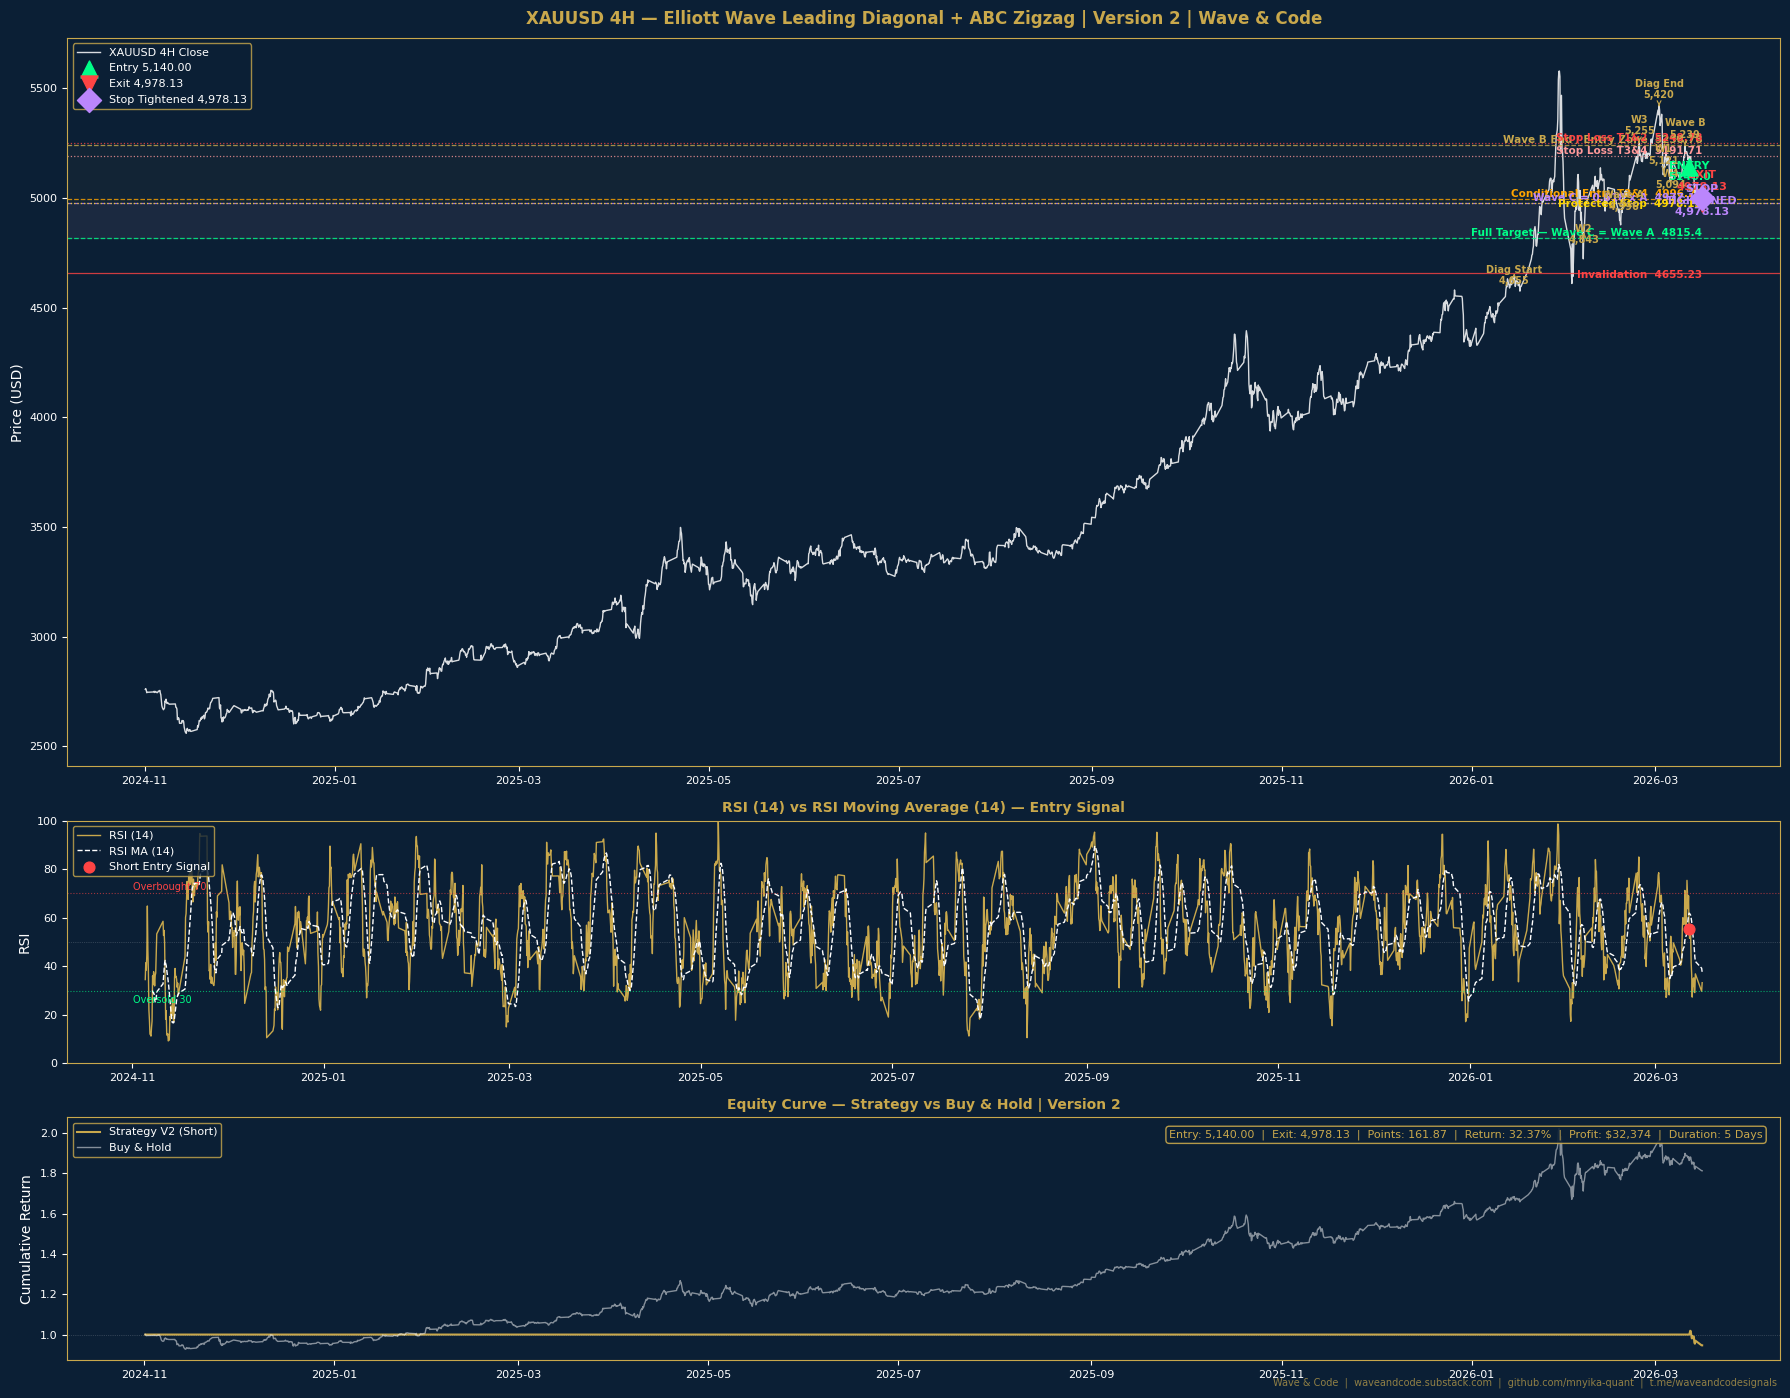

Chart saved as xauusd_elliott_wave_backtest_v2.png


In [42]:
# ============================================================
# CHART — VERSION 2 — THREE PANELS
#
# Panel 1 — Price chart with:
#   All key wave levels including Version 2 additions
#   0.618 partial exit level at 4,977.13
#   Protected stop level at 4,978.13
#   Trade entry and exit markers
#   Shaded trade zone
#
# Panel 2 — RSI with:
#   RSI line and RSI MA
#   Entry signal marked
#   Overbought and oversold reference lines
#
# Panel 3 — Equity curve with:
#   Strategy cumulative return
#   Buy and hold comparison
#   Final performance summary box
# ============================================================

NAVY   = '#0B1F35'
GOLD_C = '#C9A84C'
WHITE  = '#FFFFFF'
GREEN  = '#00FF88'
RED    = '#FF4444'
ORANGE = '#FFA500'
PURPLE = '#BB86FC'

fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1, figsize=(18, 14),
    gridspec_kw={'height_ratios': [3, 1, 1]}
)
fig.patch.set_facecolor(NAVY)

for ax in [ax1, ax2, ax3]:
    ax.set_facecolor(NAVY)
    ax.tick_params(colors=WHITE, labelsize=8)
    ax.yaxis.label.set_color(WHITE)
    ax.xaxis.label.set_color(WHITE)
    ax.title.set_color(GOLD_C)
    for spine in ax.spines.values():
        spine.set_edgecolor(GOLD_C)

# ---- PANEL 1 — PRICE ----
ax1.set_title(
    'XAUUSD 4H — Elliott Wave Leading Diagonal + ABC Zigzag'
    ' | Version 2 | Wave & Code',
    fontsize=12, fontweight='bold', pad=10
)
ax1.plot(
    gold.index, gold['Close'],
    color=WHITE, linewidth=1, alpha=0.85,
    label='XAUUSD 4H Close'
)

# Horizontal key levels
levels = [
    (WAVE_B_HIGH,         GOLD_C,    '--', f'Wave B End / Entry Zone  {WAVE_B_HIGH}',        10),
    (STOP_INITIAL,        RED,       ':',  f'Stop Loss T1&2  {STOP_INITIAL}',                10),
    (STOP_TRADES_34,      '#FF9999', ':',  f'Stop Loss T3&4  {STOP_TRADES_34}',              10),
    (CONDITIONAL_TRIGGER, ORANGE,    '--', f'Conditional Entry T3&4  {CONDITIONAL_TRIGGER}', 10),
    (WAVE_C_618,          PURPLE,    '--', f'Wave C = 0.618 x A  {WAVE_C_618}',              10),
    (PROTECTED_STOP,      '#FFD700', ':',  f'Protected Stop  {PROTECTED_STOP}',             -20),
    (TARGET,              GREEN,     '--', f'Full Target — Wave C = Wave A  {TARGET}',        10),
    (INVALIDATION,        RED,       '-',  f'Invalidation  {INVALIDATION}',                 -20),
]
for level, color, style, label, offset in levels:
    ax1.axhline(y=level, color=color, linestyle=style,
                linewidth=0.9, alpha=0.8)
    ax1.text(
        gold.index[-1], level + offset, label,
        color=color, fontsize=7.5, ha='right', fontweight='bold'
    )

# Wave point annotations
wave_annotations = [
    ('Diag Start\n4,655', DIAGONAL_START, 'below'),
    ('W1\n5,121',         5121.167,        'above'),
    ('W2\n4,843',         4842.60,         'below'),
    ('W3\n5,255',         5254.86,         'above'),
    ('W4\n5,094',         5094.07,         'below'),
    ('Diag End\n5,420',   DIAGONAL_END,    'above'),
    ('Wave A\n4,996',     WAVE_A_LOW,      'below'),
    ('Wave B\n5,239',     WAVE_B_HIGH,     'above'),
]
for label, level, position in wave_annotations:
    closest_idx = (gold['Close'] - level).abs().idxmin()
    offset      = 35 if position == 'above' else -50
    ax1.annotate(
        label,
        xy=(closest_idx, level),
        xytext=(closest_idx, level + offset),
        color=GOLD_C, fontsize=7, fontweight='bold', ha='center',
        arrowprops=dict(arrowstyle='->', color=GOLD_C, lw=0.8)
    )

# Mark trade entry on chart
if len(trade_df) > 0:
    entry_row = trade_df[trade_df['Event'] == 'ENTRY — Trades 1 & 2']
    if len(entry_row) > 0:
        entry_date  = pd.Timestamp(entry_row['Date'].iloc[0])
        entry_price = entry_row['Price'].iloc[0]
        ax1.scatter(
            entry_date, entry_price,
            color=GREEN, s=150, zorder=6,
            marker='^', label=f'Entry 5,140.00'
        )
        ax1.annotate(
            f'ENTRY\n{entry_price}',
            xy=(entry_date, entry_price),
            xytext=(entry_date, entry_price - 60),
            color=GREEN, fontsize=8, fontweight='bold', ha='center',
            arrowprops=dict(arrowstyle='->', color=GREEN, lw=0.8)
        )

# Mark trade exit on chart
if len(trade_df) > 0:
    exit_row = trade_df[trade_df['Event'].str.contains('EXIT')]
    if len(exit_row) > 0:
        exit_date  = pd.Timestamp(exit_row['Date'].iloc[-1])
        exit_price = exit_row['Price'].iloc[-1]
        ax1.scatter(
            exit_date, exit_price,
            color=RED, s=150, zorder=6,
            marker='v', label=f'Exit 4,978.13'
        )
        ax1.annotate(
            f'EXIT\n{exit_price}',
            xy=(exit_date, exit_price),
            xytext=(exit_date, exit_price + 60),
            color=RED, fontsize=8, fontweight='bold', ha='center',
            arrowprops=dict(arrowstyle='->', color=RED, lw=0.8)
        )

# Mark stop tightening event
if len(trade_df) > 0:
    tighten_row = trade_df[trade_df['Event'].str.contains('TIGHTENED')]
    if len(tighten_row) > 0:
        tighten_date  = pd.Timestamp(tighten_row['Date'].iloc[0])
        tighten_price = tighten_row['Price'].iloc[0]
        ax1.scatter(
            tighten_date, tighten_price,
            color=PURPLE, s=150, zorder=6,
            marker='D', label=f'Stop Tightened 4,978.13'
        )
        ax1.annotate(
            f'STOP\nTIGHTENED\n4,978.13',
            xy=(tighten_date, tighten_price),
            xytext=(tighten_date, tighten_price - 80),
            color=PURPLE, fontsize=8, fontweight='bold', ha='center',
            arrowprops=dict(arrowstyle='->', color=PURPLE, lw=0.8)
        )

# Shade trade zone between entry and full target
ax1.axhspan(TARGET, WAVE_B_HIGH, alpha=0.04, color=GOLD_C)

# Shade partial exit zone between 0.618 and full target
ax1.axhspan(TARGET, WAVE_C_618, alpha=0.06, color=PURPLE)

ax1.set_ylabel('Price (USD)', fontsize=10)
ax1.legend(
    loc='upper left',
    facecolor=NAVY, edgecolor=GOLD_C, labelcolor=WHITE, fontsize=8
)

# ---- PANEL 2 — RSI ----
ax2.set_title(
    'RSI (14) vs RSI Moving Average (14) — Entry Signal',
    fontsize=10, fontweight='bold'
)
ax2.plot(gold.index, gold['RSI'],
         color=GOLD_C, linewidth=1, label='RSI (14)')
ax2.plot(gold.index, gold['RSI_MA'],
         color=WHITE, linewidth=1, linestyle='--', label='RSI MA (14)')
ax2.axhline(y=70, color=RED,   linestyle=':', linewidth=0.8, alpha=0.6)
ax2.axhline(y=30, color=GREEN, linestyle=':', linewidth=0.8, alpha=0.6)
ax2.axhline(y=50, color=WHITE, linestyle=':', linewidth=0.5, alpha=0.3)
ax2.text(gold.index[0], 71.5, 'Overbought 70', color=RED,   fontsize=7)
ax2.text(gold.index[0], 25.0, 'Oversold 30',   color=GREEN, fontsize=7)
ax2.set_ylabel('RSI', fontsize=10)
ax2.set_ylim(0, 100)

# Mark entry signals
entry_signals = gold[
    gold['RSI_cross_below'] & (gold['Close'] < WAVE_B_HIGH)
    & (gold.index >= WAVE_B_DATE)
]
if len(entry_signals) > 0:
    ax2.scatter(
        entry_signals.index, entry_signals['RSI'],
        color=RED, s=60, zorder=5, label='Short Entry Signal'
    )
ax2.legend(
    loc='upper left',
    facecolor=NAVY, edgecolor=GOLD_C, labelcolor=WHITE, fontsize=8
)

# ---- PANEL 3 — EQUITY CURVE ----
ax3.set_title(
    'Equity Curve — Strategy vs Buy & Hold | Version 2',
    fontsize=10, fontweight='bold'
)
ax3.plot(gold.index, gold['cumulative_strategy'],
         color=GOLD_C, linewidth=1.5, label='Strategy V2 (Short)')
ax3.plot(gold.index, gold['cumulative_market'],
         color=WHITE, linewidth=1.0, alpha=0.5, label='Buy & Hold')
ax3.axhline(y=1, color=WHITE, linestyle=':', linewidth=0.5, alpha=0.3)
ax3.set_ylabel('Cumulative Return', fontsize=10)

# Performance summary box — Version 2 final results
perf_text = (
    f'Entry: 5,140.00  |  '
    f'Exit: 4,978.13  |  '
    f'Points: 161.87  |  '
    f'Return: 32.37%  |  '
    f'Profit: $32,374  |  '
    f'Duration: 5 Days'
)
ax3.text(
    0.99, 0.95, perf_text,
    transform=ax3.transAxes,
    ha='right', va='top', color=GOLD_C, fontsize=8,
    bbox=dict(boxstyle='round', facecolor=NAVY,
              edgecolor=GOLD_C, alpha=0.9)
)
ax3.legend(
    loc='upper left',
    facecolor=NAVY, edgecolor=GOLD_C, labelcolor=WHITE, fontsize=8
)

# Watermark
fig.text(
    0.99, 0.005,
    'Wave & Code  |  waveandcode.substack.com  |  '
    'github.com/mnyika-quant  |  t.me/waveandcodesignals',
    ha='right', va='bottom', color=GOLD_C, fontsize=7, alpha=0.7
)

plt.tight_layout()
plt.savefig(
    'xauusd_elliott_wave_backtest_v2.png',
    dpi=150, bbox_inches='tight', facecolor=NAVY
)
plt.show()
print('Chart saved as xauusd_elliott_wave_backtest_v2.png')


In [43]:
trade_df.to_csv('trade_log.csv', index=False)
print('Trade log saved as trade_log.csv')


Trade log saved as trade_log.csv


In [44]:
print(f'Total trade events:  {len(trade_df)}')
print(f'Unique event types:')
print(trade_df['Event'].value_counts())
print()
print(f'First trade:')
print(trade_df.head(2).to_string(index=False))
print()
print(f'Last trade:')
print(trade_df.tail(2).to_string(index=False))
print()
print(f'Date range of trades:')
print(f'  First: {trade_df["Date"].iloc[0]}')
print(f'  Last:  {trade_df["Date"].iloc[-1]}')

Total trade events:  3
Unique event types:
Event
ENTRY — Trades 1 & 2                            1
STOP TIGHTENED TO 4,978.13 — T3&4 NOT ACTIVE    1
EXIT T1&2 — STOP HIT 4978.13                    1
Name: count, dtype: int64

First trade:
                                       Event                      Date  Price  Lots    Stop  Locked Profit  Running Profit  Total Equity
                        ENTRY — Trades 1 & 2 2026-03-11 20:00:00+00:00 5140.0     2 5248.78            0.0            0.00     100000.00
STOP TIGHTENED TO 4,978.13 — T3&4 NOT ACTIVE 2026-03-15 20:00:00+00:00 5000.6     2 4978.13            0.0        27879.98     127879.98

Last trade:
                                       Event                      Date   Price  Lots    Stop  Locked Profit  Running Profit  Total Equity
STOP TIGHTENED TO 4,978.13 — T3&4 NOT ACTIVE 2026-03-15 20:00:00+00:00 5000.60     2 4978.13            0.0        27879.98     127879.98
                EXIT T1&2 — STOP HIT 4978.13 2026-03-16 00:00

In [45]:
from google.colab import files
files.download('xauusd_elliott_wave_backtest_v2.png')
files.download('trade_log_v2.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>